In [1]:
import os
import time
import math
import tqdm
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.utils.data
import torch.nn.functional as F
from torchsummary import summary
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter
from torch.autograd.function import InplaceFunction, Function

import biosppy as bio

import shutil
import subprocess
import itertools
from pathlib import Path
from datetime import datetime
from collections import deque

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn import preprocessing

#%matplotlib notebook
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('../')

# Physionet Specific imports
from driver import load_challenge_data
from driver import get_classes

# compute_auc(labels, probabilities, num_classes, check_errors=True)
from evaluate_12ECG_score import compute_auc
# compute_beta_score(labels, output, beta, num_classes, check_errors=True)
from evaluate_12ECG_score import compute_beta_score

from src.data.helper import snomed_to_text

In [2]:
from upsetplot import generate_counts
import upsetplot as upset
from upsetplot import from_memberships

In [3]:
DATALOADER_WORKER = 0
base_path = Path('../')
input_path = base_path.joinpath('data/raw/complete')
print(input_path.resolve().absolute())

/Users/opt/projects/docker-env/physionet2020/data/raw/complete


# Data Label Distribution

In [4]:
# Get all the unique labels
labels = []
for file in tqdm.tqdm(input_path.iterdir()):
    if file.name.split('.')[0].split('_')[-1] == 'class':
        clss = np.load(file)
        labels.append([str(cls) for cls in clss])

41320it [00:05, 7099.33it/s]


In [5]:
# Number of classes
unique = np.unique(list(itertools.chain(*labels)))
nlabels = { key : 0 for key in list(unique) }

# Count the number of 
for key in itertools.chain(*labels):
    nlabels[key] += 1

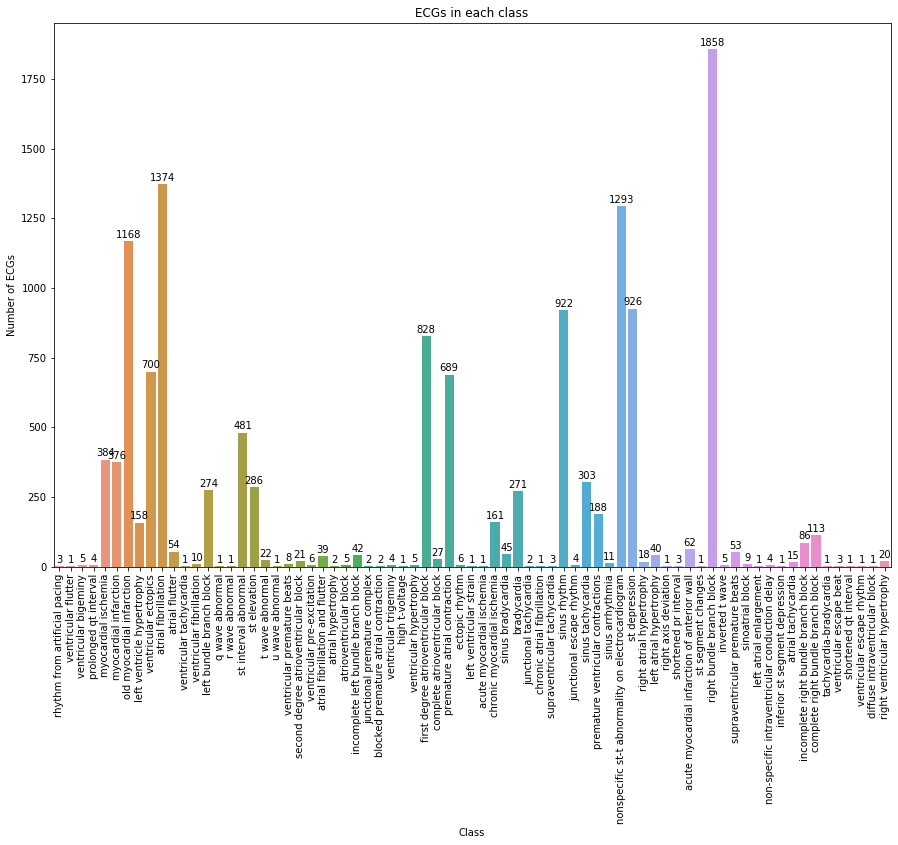

In [6]:
plt.figure(figsize=(15,10))
text_labels = [snomed_to_text(k) for k in list(nlabels.keys())]
ax = sns.barplot(text_labels, list(nlabels.values()))

plt.title("ECGs in each class")
plt.ylabel('Number of ECGs')
plt.xlabel('Class')

rects = ax.patches
slabels = list(nlabels.values())
for rect, label in zip(rects, slabels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 5, label, ha='center', va='bottom')
plt.xticks(rotation=90)
plt.show()

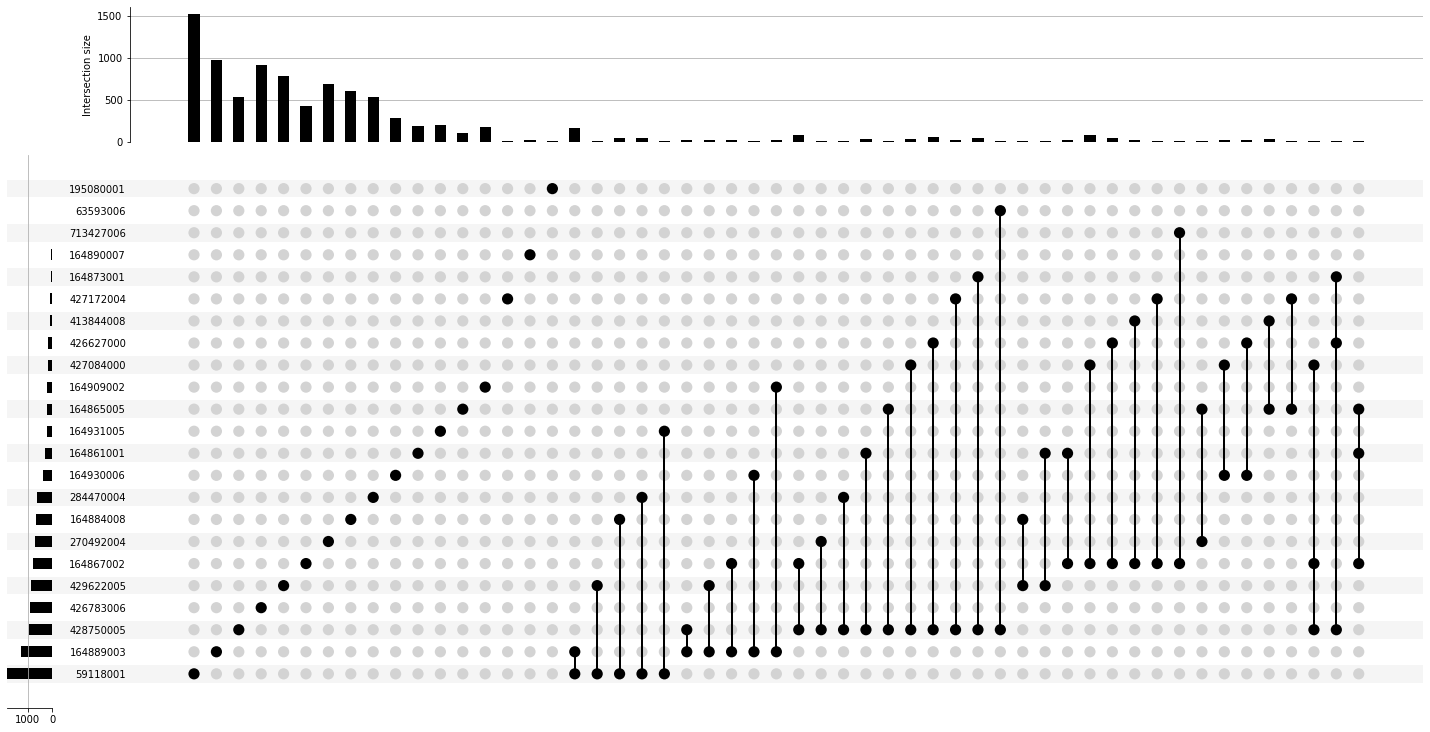

In [7]:
# Look at the multilabel cases!
lbl, cnt = np.unique(labels, return_counts=True)

lbl = lbl[cnt > 10]
cnt = cnt[cnt > 10]

category_membership = from_memberships(lbl, cnt)
#category_membership.index.names = [snomed_to_text(k) for k in category_membership.index.names]
upset.plot(category_membership, subset_size='auto')
plt.show()

# Meta Data (Age + Sex)

In [8]:
# Load meta data (age + sex) and their corresponding classes

sex = []; age = []; clsss = []
for file in tqdm.tqdm(input_path.iterdir()):
    if file.name.split('.')[0].split('_')[-1] == 'meta':
        clss = np.load(input_path.joinpath(file.name.split('.')[0].replace('_meta', '_class') + '.npy'))
        meta = np.load(file)
        age.append(meta[0])
        sex.append(meta[1])
        clsss.append([str(cls) for cls in clss])

41320it [00:08, 4735.99it/s]


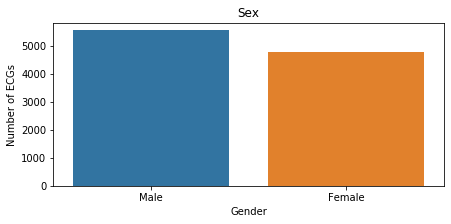

In [9]:
fig = plt.figure(figsize=(7,3))

sex_dict = {'Male' : sex.count(0), 'Female' : sex.count(1)}
ax = sns.barplot(list(sex_dict.keys()), list(sex_dict.values()))

plt.title("Sex")
plt.ylabel('Number of ECGs')
plt.xlabel('Gender')

plt.show()

Text(0.5, 1.0, 'Age distribution by sex')

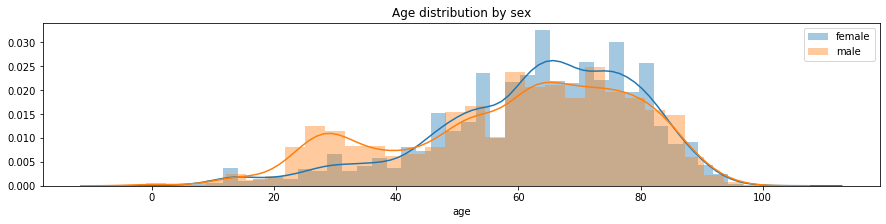

In [10]:
sex = np.array(sex)
age = np.array(age)
f = np.argwhere(sex==0)
m = np.argwhere(sex==1)
fig = plt.figure(figsize=(15,3))
sns.distplot(age[f], label='female')
sns.distplot(age[m], label='male')
plt.legend()
plt.xlabel('age')
plt.title('Age distribution by sex')

In [11]:
dist = pd.DataFrame(np.zeros((1,3)), columns=['age', 'dx', 'sex'])

unique = np.unique(list(itertools.chain(*labels)))
for i, clss in enumerate(clsss):
    for cl in clss:
        dist.loc[i, ['age', 'dx', 'sex']] = [age[i], cl, sex[i]]

# Ok, there are people really young (-1 year old)
dist[dist["age"] > 0].describe()['age']

count    10318.000000
mean        61.398721
std         17.976630
min          1.000000
25%         51.000000
50%         64.000000
75%         75.000000
max        104.000000
Name: age, dtype: float64

In [12]:
select = dist["dx"].value_counts() > 10
select = select[select].keys()
fdist = dist[dist["dx"].isin(select)]

print("Selecting:", len(fdist), "from:", len(dist))

Selecting: 10259 from: 10330


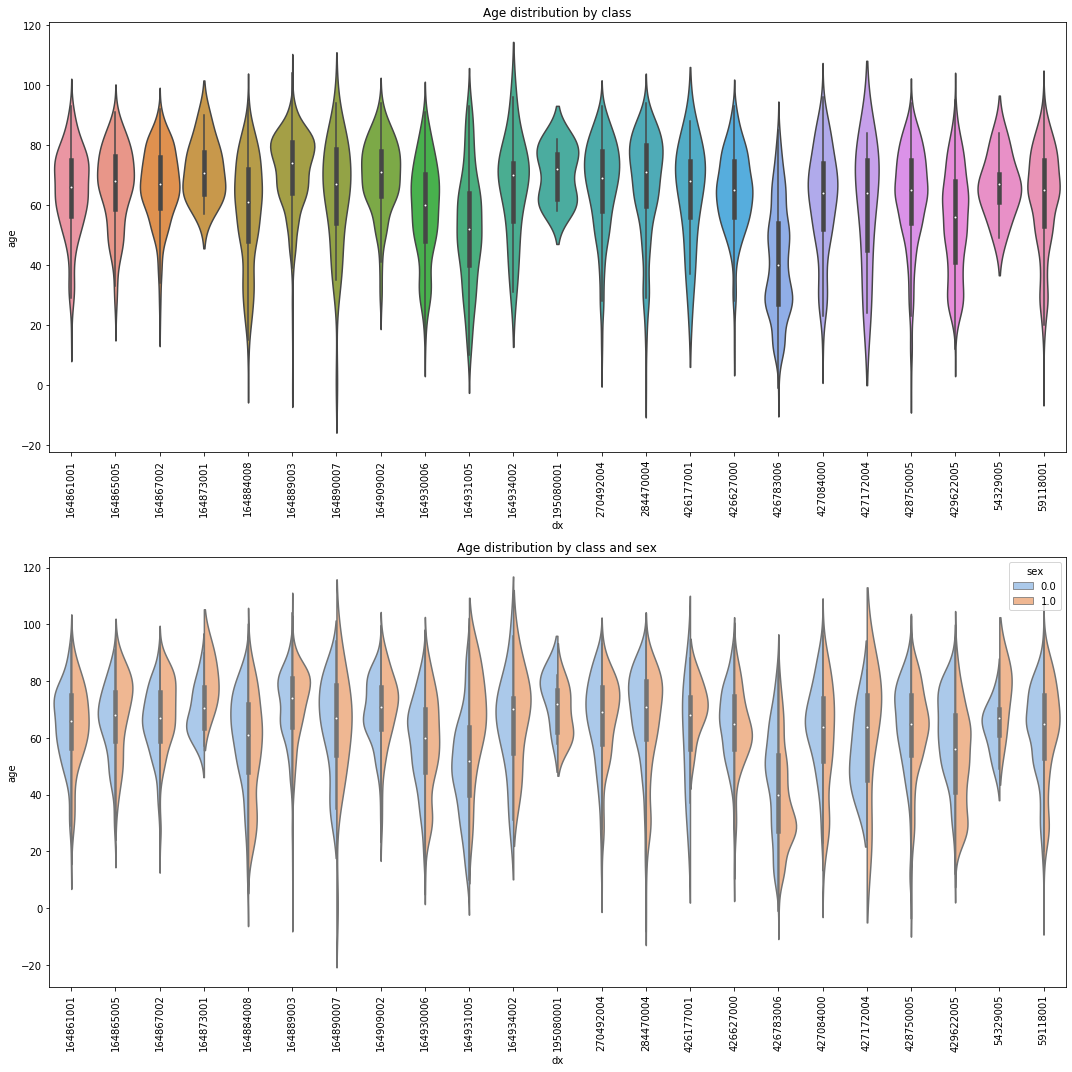

In [13]:
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(211)

sns.violinplot(x='dx', y='age', data=fdist, ax=ax, width=1)
plt.title('Age distribution by class')
plt.xticks(rotation=90)

ax = fig.add_subplot(212)
sns.violinplot(x='dx', y='age', hue='sex', split=True, palette='pastel', data=fdist)
plt.title('Age distribution by class and sex')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# Data length

In [14]:
length = []; clsss = []
for file in tqdm.tqdm(input_path.iterdir()):
    if file.name.split('.')[0].split('_')[-1] == 'data':
        clss = np.load(input_path.joinpath(file.name.split('.')[0].replace('_meta', '_class') + '.npy'))
        length.append(np.load(file).shape[1] / 500)
        clsss.append([str(cls) for cls in clss])

41320it [00:34, 1198.49it/s]


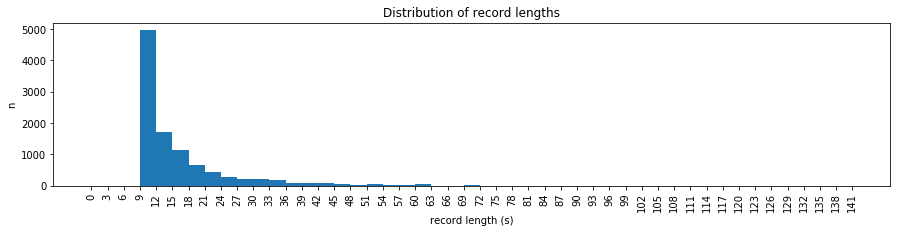

min (s):  6.0
max (s):  144.0
most present length (s):  3
lengths over 60 s:  [ 69. 138. 118. 132.  71.  73.  61.  73.  65. 144. 112.  69.  85.  97.
  70.  74.  74.  98.  88.  74.  85.  62.  64.  98.  66.  65.  61. 101.
 118.  66.  95.  68.  66.  70.  88.  71.  61.]


In [15]:
fig = plt.figure(figsize=(15,3))

bins = np.arange(0, np.max(length), 3)
hist, _, _ = plt.hist(length, bins=bins)

plt.xticks(bins, rotation=90)
plt.xlabel('record length (s)')
plt.ylabel('n')
plt.title('Distribution of record lengths')
plt.show()

length = np.array(length)
print('min (s): ', np.min(length))
print('max (s): ', np.max(length))
print('most present length (s): ', np.argmax(hist))
overlong = np.where(length > 60, 1, 0)
overlong = np.nonzero(overlong)[0]
print('lengths over 60 s: ', length[overlong])